# **MVAR - 6) Análisis de conglomerados**
    
El objetivo es formar grupos de observaciones, de manera que todas las unidades en un grupo sean similiares entre ellas, pero distintas a aquellas en otros grupos. Generalmente no se sabe el número de grupos ni el número de elementos en cada uno, por lo que las técnicas descritas en este NB son llamadas _"no supervisadas"_. Una de las diferencias entre métodos de análisis de conglomeración es la definición de lo que es "similar", por lo que diversas definiciones dan pie a diversos métodos.
    
> 1) Jerárquicos aglomerativos
> 2) Jerárquicos divisivos
> 3) No jerárquicos

## **6.0) Marco teórico**

### **6.1) Inercia**

Es una métrica utilizada para evaluar qué tan bien los datos se agrupan en relación con sus respectivos centros de los clústeres. Se refiere a la suma de las distancias cuadráticas entre cada punto de datos y el centroide del clúster al que pertenece. Cuanto menor sea la inercia, mejor será la agrupación de los puntos en los clústeres, ya que las distancias de los puntos a los centroides serán más pequeñas, lo que indica que los putnos están más cerca de los centroides.

En términos fomlaes, para $n$ observaciones agrupadas en $k$ grupos, donde el número de elementos en el grupo $i$ es $N_i$

> $Inercia = \displaystyle \sum^k_{i=1} \sum_{j=1}^{N_i} \| x_j - \mu_j \|^2$


Observe que si se tiene el mismo número de grupos como de observaciones, la inercia sería igual a $0$.



### **6.2) Silueta**

Otra de las técnicas utilizadas para comparar modelos de clusterización es la siueta. Un análisis de sikueta se realiza a través de la comparación de la **puntuación de silueta** de cada modelo. Para calcular el coeficiente de silueta $S(i)$ para el individuo $i$ se utilizan las siguientes definiciones:

> $a(i): \quad$ La distancia media entre un individuo _i_ y el resto de individuos dentro del mismo cluster.
> 
> $b(i): \quad$ La distancia media del individuo $i$ y los elementos del cluster ajeno que la minimice
> 
> $S(i) = \dfrac{b(i) - a(i)}{max\left[ a(i), b(i) \right] }$

Observe que $S(i) \in (-1,1)$. Por lo tanto:  
> $S(i) \approx 1 \quad:$ Implica que el individuo $i$ está cerca de otros individuos de su propio cluster, separado de los elementos en otros clusters.
>
> $S(i) \approx 0 \quad:$ Implica que el elemento se encuentre en la frontera de dos clusters, por lo que  no es muy claro a cual pertenece
>
> $S(i) \approx -1 \quad:$ Implica que el elemento se encuentra más cerca de los elementos en otro cluster que de los elementos al cual fue asignado.

La **puntuación de Silueta** es la media sobre todos los elementos de los coeficientes de silueta. Entre más alta sea la puntuación, el modelo es mejor, porque los elementos de un cluster están cercanos y los clusters están alejados entre si.

### **6.3) Intervalo de confianza en normal multivariada**

Sea $\boldsymbol{X} \sim N_n(\vec{\mu}, \Sigma)$, el intervalo de confianza multivariado abarca una región en el espacio de múltiples dimensiones donde se estima que los parámetros verdaderos se encuentran con una probabilidad específica.

En lugar de un intervalo como en en el caso unidimensional, el intervalo de confianza en una normal multivariada es típicamente una elipse (en 2 dimensiones) o un elipsoide (en dimensiones superiores). Esto se debe a que la distribución normal multivariada tiene una densidad en forma de elipsoide alrededor de $\vec{\mu}$

La región de confianza de nivel $1-\alpha$ para el vector $\boldsymbol{x}$ puede representarse como:

> $\left\{ \left( \boldsymbol{x} - \vec\mu}{ \right)^T \hat{\Sigma}^{-1} \left( \boldsymbol{x} - \vec{\mu} \right) \leq \chi^2_{n, (1-\alpha)} \right\}$

Para obtener la forma de la elipse se descompone $\Sigma$ en su forma cuadratica, utilizando los eigenvectores y valores característicos

> $\Sigma = V \Lambda V^T$
>
> $donde:$ $V = [v_1, v_2, ..., v_n]$ $\quad y \quad$ $\Lambda=diag(\lambda_1, \lambda_2, ..., \lambda_n)$

En el caso de 2 dimensiones, la elipse de confianza puede ser representada en coordenadas polares como:

> $Ellipse(t) = \vec{\mu} + \begin{bmatrix} \sqrt{\chi^2_{n, (1-\alpha)} \lambda_1} cos(t) \\ \sqrt{\chi^2_{n, (1-\alpha)} \lambda_1} sen(t) \end{bmatrix} \quad;\quad t\in[0,2\pi]$

Note que el procedimiento de elipses de confianza puede utilizarse para realizar pruebas de hipótesis en contextos multivariados. En el caso en el que se tenga que estimar $\Sigma$ con $S^2$, la distribución $T^2$ de Hotelling es la adecuada para tal propósito.


## **6.1) Preparar para la ejecución**

### **6.1.1) Cargar librerías**

In [247]:
# General use
import os
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style(style="ticks")
sns.set_palette("Set2")
from mpl_toolkits.mplot3d import Axes3D

# Hierarchical custer analysis
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage as scipy_linkage
from itertools import cycle, islice
from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

# Non.hierarchical methods
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# Gaussian mixture
from sklearn.mixture import GaussianMixture

# Implement clustering algorithms
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import manhattan_distances

### **6.1.2]  Cargar base de datos**

Se utiliza la base de datos con los primeros 151 Pokemones y sus _stats_ dentro del juego. Chansey se elimina por ser outlier.

In [2]:
# Read data
main_folder = os.getcwd()
df_data = pd.read_csv(main_folder + "/Data/Pokemon.csv", index_col=0)
df_data.index.name = "Number"
df_data.rename(columns={"Sp. Atk": "Sp. Attack", "Sp. Def": "Sp. Defense"}, inplace=True)

# Select first generation pokemons
df_data = df_data[~df_data["Name"].str.contains("Mega", regex=False)]
df_data = df_data[df_data["Generation"]==1].copy()

# Define cuantiative columns
features = ["HP", "Attack", "Defense", "Sp. Attack", "Sp. Defense"]

# Remove Chansey
df_data = df_data[df_data["Name"] != "Chansey"].copy()

# Display database
df_data.head(5)

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Attack,Sp. Defense,Speed,Generation,Legendary
Number,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
4,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False


## **6.2) Análisis exploratorio de datos**

Con el fin de previsualizar la posible formación de conglomerados, se realiza una proyección multivariada en dos  dimensiones a través de MDS.

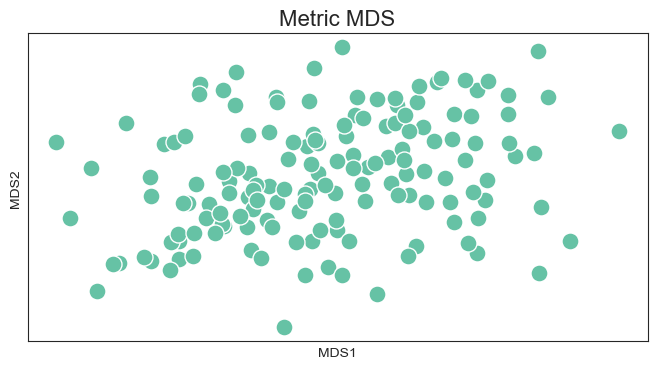

In [3]:
# Calculate MDS based on city block distances
dist_manhattan = manhattan_distances(df_data[features])
model_mds = MDS(n_components=2, dissimilarity="precomputed", metric=True, random_state=314159)
df_data[["MDS1", "MDS2"]] = model_mds.fit_transform(dist_manhattan)


# Plot results
plt.figure(figsize=(8,4))
sns.scatterplot(x="MDS1", y="MDS2", data=df_data, s=150)
plt.xticks([]), plt.yticks([]), plt.title("Metric MDS", fontsize=16)
plt.show()

## **6.3) Métodos aglomerativos jerárquicos**

### **6.3.1) Ajustar modelos**

Dan origen a un gráfico llamado dendograma que muestra la secuencia de unión entre grupos, **al final, todo  el set de datos se une en un solo grupo**. Al inicio del algoritmos cada observación es considerada un  conglomerado por si mismo, y con la  secuencia de los pasos, cada conglomerado va adquiriendo nuevos elementos.
    
Son métodos iterativos y al final de cada paso debe recalcularse la distancia entre elementos. Por lo que correr el algoritmo para un set con muchas observaciones puede ser lento.
    
Primero se debe definir cómo se mide la distancia entre cada elemento. P.ej. Euclideana, Manhattan, etc. Después, al ir aglomerando puntos, se debe definir cómo se mide la distancia entre conglomerados. Este proceso da nombre a los distintos métodos. Po ejemplo, existe:
        
> 1) Liga sencilla: Se unen los conglomerados con la distancia mínima entre todas las posibles distancias entre objetos que pertenecen a distintos conglomerados. También se le llama la de vecino más próximo.
>
> 2) Liga completa: Se define la distancia entre conglomerados como la máxima de todas las posibles  distancias entre elementos de distintos conglomerados; se unen los dos conglomerados más cercanos.
>       
> 3) Liga promedio: Se toma el promedio de todas las posibles distancias entre elementos que pertenecen a  distintos conglomerados.
>
> 4) Método de Ward: Une elementos a conglomerados de tal manera que minimiza la suma de cuadrados de las  distancias al centroide de los conglomerados y el potencial nuevo conglomerado.
        
El dendograma proporciona una representación visual y jerárquica de las relaciones entre datos, lo que puede ayudar a identificar patrones y estructuras en el conjunto de datos. Ayuda a entender como los elementos individuales o grupos de datos están relacionados entre sí. Los  grupos o elementos más cercanos comparten características más similares que aquellos más alejados. Cada rama del dendrograma representa una conexión entre grupos o elementos, y la longitud de las  ramas indica la distancia entre ellos. En la parte inferior se encuentran los elementos individuales antes de que se agrupen en estructuras más grandes.

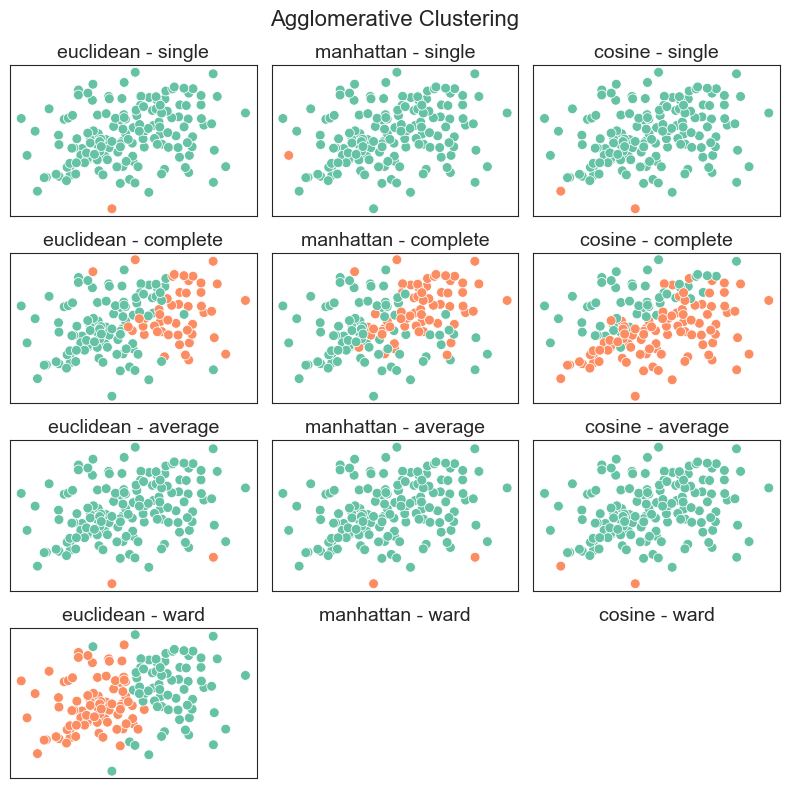

In [4]:
# Define combinations of metric and linkages
combinations = [[metric, linkage] for metric in ["euclidean", "manhattan", "cosine"] for linkage in ["single", "complete", "average", "ward"]]

# Define plotting grid
fig, axes = plt.subplots(4,3, figsize=(8,8))

# Run algorithm for different linkages
linkages = ["single", "average", "complete"]
for i,combination in enumerate(combinations):
    j = i//4
    i = i%4

    # Define settings to run model
    metric, linkage = combination
    
    # Check if it's possible to run the algorithm
    valid = False if (metric!="euclidean") and (linkage=="ward") else True
    if valid:
    
        # Fit agglomerativ cluster model
        model_aggcluster = AgglomerativeClustering(n_clusters=2, linkage=linkage, metric=metric)
        model_aggcluster.fit(df_data[features])
    
        # Show results
        sns.scatterplot(x="MDS1", y="MDS2", data=df_data, hue=model_aggcluster.labels_, palette="Set2", s=50, legend=False, ax=axes[i,j])
    
    # In case of "ward" linkage for no euclidean, remove axis of plots
    else:
        axes[i,j].axis('off')
    
    # Don't show ticks, regardless if it's a valid combination or not
    axes[i,j].set_xticks([]), axes[i,j].set_yticks([]), axes[i,j].set_ylabel(""), axes[i,j].set_xlabel("")
    axes[i,j].set_title(metric+" - "+linkage, fontsize=14)

# Show plot
plt.suptitle("Agglomerative Clustering", fontsize=16)
plt.tight_layout()
plt.show()

### **6.3.2) Dendograma**

Representación gráfica en forma de árbol que muestra las relaciones entre los elementos del conjunto de datos. Permite conocer la forma en que cada elemento se agrupo en cada pasa sucesivo del algoritmo. Eventualmente todos los grupos convergen a un mismo conglomerado, por lo qeu al trazar una línea horizontal es posible definir el número de grupos resultantes que se quisieran obtener.

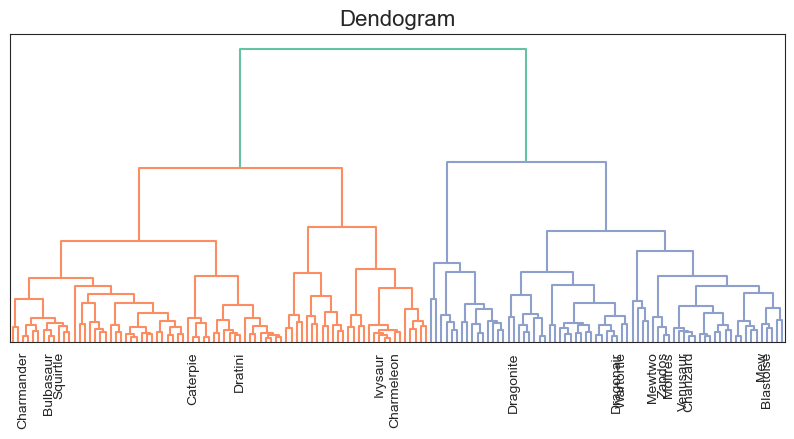

In [5]:
# Define function to display specific labels in the dendogram
def llf(id):
    if id > 142 or id < 10:
        return str(df_data["Name"].iloc[id])
    else:
        return ""

# Prepare for plotting
plt.figure(figsize=(10,4))

# Compute dendogram
Z = scipy_linkage(np.array(df_data[features]), method="ward", metric="euclidean")
D = dendrogram(Z, leaf_rotation=90, leaf_label_func=llf,leaf_font_size=10)

# Show plot
plt.title("Dendogram", fontsize=16), plt.yticks([])
plt.show()

### **6.3.3) Influencia de la liga en el algoritmo**

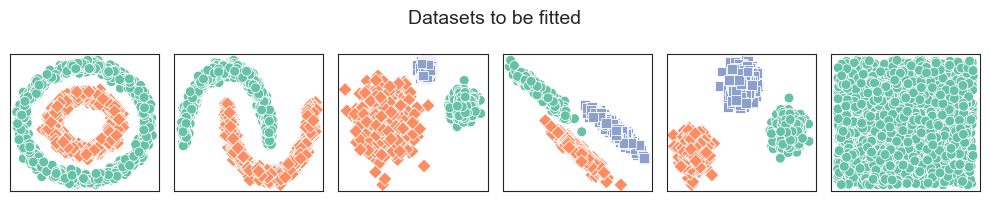

In [209]:
# Generate circles, rings and blobs
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=170)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=12345)

# No structure
random = np.random.RandomState(170)
no_structure = random.rand(n_samples, 2), np.full(n_samples, 0)

# Anisotropicly distributed data
X, y = datasets.make_blobs(n_samples=n_samples, random_state=17)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
uneven = datasets.make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=12345)

# Gather together all datasets with metadata
list_datasets = [("Noisy Circles", noisy_circles, {"n_clusters":2}),
                ("Noisy Moons", noisy_moons, {"n_clusters":2}),
                ("Uneven Variance", uneven, {"n_clusters":3}),
                ("Anisotropic", aniso, {"n_clusters":3}),
                ("Blobs", blobs, {"n_clusters":3}),
                ("No Structure", no_structure, {"n_clusters":2})]

# Create plot grid
fig, axes = plt.subplots(1,6, figsize=(10,2))

# Plot every dataset
for i, dataset in enumerate(list_datasets):
    name = dataset[0]
    X = dataset[1][0]
    y = dataset[1][1]
    sns.scatterplot(x=X[:,0], y=X[:,1], ax=axes[i], hue=y, legend=False, palette="Set2", s=50,
                   style=y, markers={0:"o", 1:"D", 2:"s"})
    axes[i].set_xticks([]), axes[i].set_yticks([])

# Show figure
plt.suptitle("Datasets to be fitted", fontsize=14)
plt.tight_layout()
plt.show()

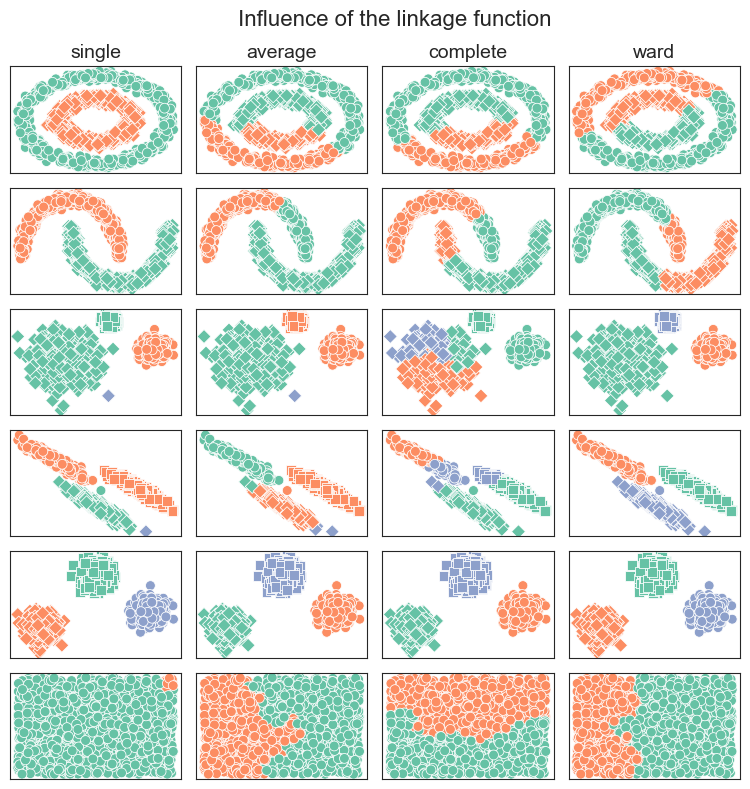

In [204]:
# Define linkage functions to be used and the plot grid
linkages = ["single", "average", "complete", "ward"]
fig, axes = plt.subplots(6,4, figsize=(8,8))

# Iterate over every dataset
for i,dataset in enumerate(list_datasets):
    
    # Metadata of the dataset in iteration
    name = dataset[0]
    X = dataset[1][0]
    y = dataset[1][1]
    target = dataset[2]["n_clusters"]

    # Iterate over all linkage functions and change columns
    j = 0
    for linkage in linkages:
        
        # Fit model for a given dataset and linkage function
        model_aggcluster = AgglomerativeClustering(n_clusters=target, linkage=linkage, metric="euclidean")
        model_aggcluster.fit(X)

        # Plot results of agglomerative clustering
        sns.scatterplot(x=X[:,0], y=X[:,1], hue=model_aggcluster.labels_, legend=False, ax=axes[i,j], palette="Set2", s=50,
                       style=y, markers={0:"o", 1:"D", 2:"s"})
        axes[i,j].set_xticks([]), axes[i,j].set_yticks([])
        if i==0:
            axes[i,j].set_title(linkage, fontsize=14)
        
        # Jump to next column in grid plot
        j += 1

# Show plot
plt.suptitle("Influence of the linkage function", fontsize=16)
plt.tight_layout(rect=[0,0,0.95,1])
plt.show()

### **6.3.4) Análisis de silueta**

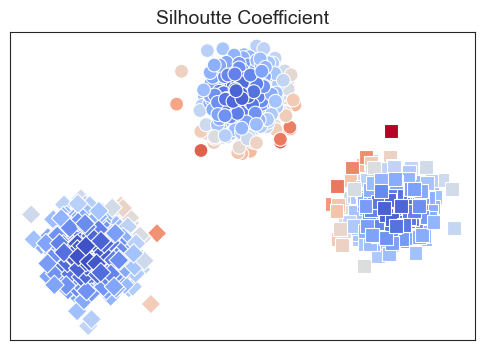

In [26]:
model_aggcluster = AgglomerativeClustering(n_clusters=3, linkage="ward", metric="euclidean").fit(blobs[0])

sil_coef = silhouette_samples(blobs[0], model_aggcluster.labels_)

plt.figure(figsize=(6,4))
sns.scatterplot(x=blobs[0][:,0], y=blobs[0][:,1], hue=sil_coef, s=100, palette="coolwarm_r",
               style=model_aggcluster.labels_, markers={0:"o",1:"D",2:"s"}, legend=False)

plt.xticks([]), plt.yticks([]), plt.xlabel("",fontsize=12), plt.ylabel("",fontsize=12)
plt.title("Silhoutte Coefficient", fontsize=14)
plt.show()

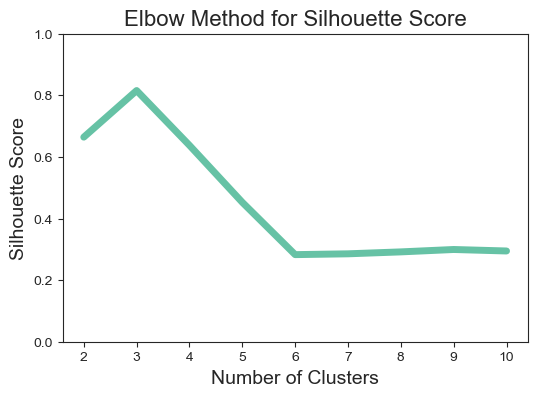

In [9]:
sil_score = []
for k in range(2,11):
    model_aggcluster = AgglomerativeClustering(n_clusters=k, linkage="ward", metric="euclidean").fit(blobs[0])
    sil_score += [silhouette_samples(blobs[0], model_aggcluster.labels_).mean()]

plt.figure(figsize=(6,4))
sns.lineplot(x=[i for i in range(2,11)], y=sil_score, linewidth=5)
plt.ylabel("Silhouette Score", fontsize=14), plt.xlabel("Number of Clusters", fontsize=14), plt.ylim(0, 1)
plt.title("Elbow Method for Silhouette Score", fontsize=16)
plt.show()

## **6.4) Métodos aglomerativos no jerárquics**

Son un enfoque de agrupamiento (_clustering_) en el que el conjunto de datos se divide en grupos previamente especificados (o determinados por un cirterio de optimización). A diferencia de los métodos jerárquicos, donde los clusters se construyen formando una jerarquía de divisiones sucesivas (ya sea de manera aglomeativa o divisiva), los métodos particionales comienzan con una partición inicial y la ajusta interativamente para mejorar la asignación de los individuos a los clusters.

Alguinas de las **características principales** son:  

> - Número de Clusters predefinido: Se debe especificar (_k_) antes de ejecutar el algoritmo.
>
> - Optimización iterativa: Los puntos de datos se asignan a los clusters de forma iterativa para minimizar o maximizar algún criterio de optimización, como la varianza intra-clase o la distancia entre clusters
>
> - Formación de Clusters: Estos métodos no crean una jerarquía de clusters, sino que intentan encontrar una partición óptima de los datos ajustando continuamente las asignaciones de los individuos a los clusters

A continuación se presentan algunos de los algoritmos más comunes.

### **6.4.1) Método de _k-means_**

Algoritmo de lcusterización que agrupo los datos en _k_ clusters basados en la similitud entre los puntos, donde el valor de _l_ debe definirse previamente. El proceso comienza seleccionando _k_ centroides iniciales que pueden elegirse aleatoriamente mediante un método como _k-means++_. Posteriormente, los puntos se asignan al cluster cuyo centroide esté más cercano, y los centroides se actualizan recalculando el promedio de los puntos en cada uno. Este ciclo de asignación y actualización se repite haste que los centroides dejan de cambiar significativamente.

Aunque _k.means_ es eficiente y fácul de implementar, tiene algunas desventajas. El valor de k no siempre es evidente, y una mala elección puede afectar los resultados. Además, el algoritmo es sensible a los valores iniciales d elos centroides y puede no funcionar bien con clusters de formas o tamaños muy diferentes. También es vulnerable a valores atíppicos (_outliers_). , que pueden distorsionar los clusters.

#### **6.4.1.1) Ajustar modelos y curva de _elbow_**

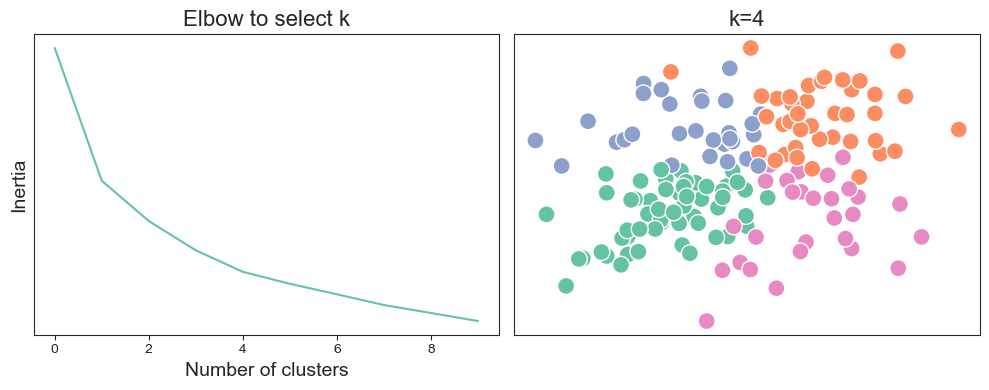

In [10]:
inertias = []

for k in range(1,11):
    model_kmeans = KMeans(n_clusters=k, random_state=314159, n_init=25)
    model_kmeans.fit(X=np.array(df_data[features]))
    inertias += [model_kmeans.inertia_]


# Plot elobow curve
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,4))
sns.lineplot(inertias, ax=ax1)
ax1.set_yticks([]), ax1.set_ylabel("Inertia",fontsize=14), ax1.set_xlabel("Number of clusters",fontsize=14)
ax1.set_title("Elbow to select k", fontsize=16)


# Run model with k=4 and plot it
model_kmeans = KMeans(n_clusters=4, random_state=3, n_init=25)
model_kmeans.fit(X=np.array(df_data[features]))
sns.scatterplot(x="MDS1", y="MDS2", data=df_data, s=150, hue=model_kmeans.labels_, palette="Set2", ax=ax2, legend=False)
ax2.set_xticks([]), ax2.set_yticks([]), ax2.set_xlabel(""), ax2.set_ylabel("")
ax2.set_title("k=4", fontsize=16)

# Show plot
plt.tight_layout()
plt.show()

#### **6.4.1.2) Compresión de imágenes con _k-means_**

Primero se carga la imagen que será sometida a compresión.

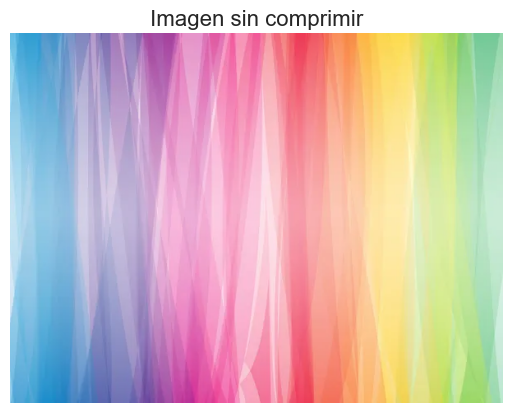

In [11]:
image = plt.imread(main_folder+"/Data/image.jpg")

plt.imshow(image)
plt.axis("off")
plt.title("Imagen sin comprimir", fontsize=16)
plt.show()

Se muestra que cada pixel tiene su propio color en un espacio RGB.

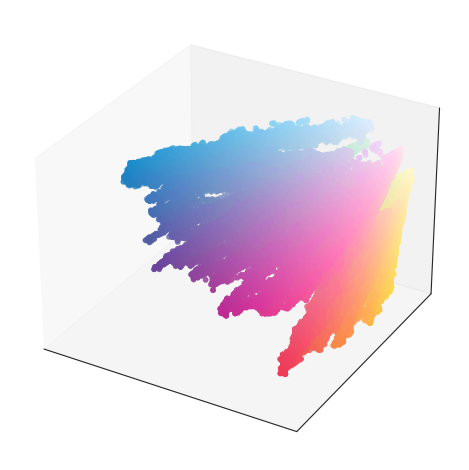

In [12]:
# Create DF with RGB of flatten pixels
df_image = pd.DataFrame(data=image.reshape(image.shape[0]*image.shape[1],3), columns=["red", "green", "blue"])

# Auxiliary to plot scatter plot of pixels and its color
red = df_image["red"]
green = df_image["green"]
blue = df_image["blue"]

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Plot scatter plot
ax.scatter(red, green, blue, marker="o", c=df_image.values/255, s=10)
ax.set_xlabel(""), ax.set_ylabel(""), ax.set_zlabel("")
ax.set_xticks([]), ax.set_yticks([]), ax.set_zticks([])

# Show image
plt.tight_layout()
plt.show()

La compresión se basa en reducir la escala RGB con  16,581,375 de colores ($255^3$) a una selección de $k$ colores distinitos.

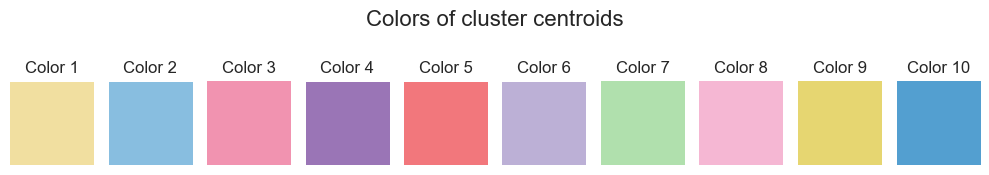

In [13]:
# Fit kmeans model for every pixel in an RGB space
model_kmeans = KMeans(n_clusters=10, random_state=314159, n_init=25)
model_kmeans.fit(df_image.values)

# Create plots grid
fig, axes = plt.subplots(1,10, figsize=(10,2))

# Plot cluster centroids in an RGB space
for i,rgb in enumerate(model_kmeans.cluster_centers_):
    rgb = [[rgb.astype(int)]]
    axes[i].set_title("Color "+str(i+1)), axes[i].imshow(rgb), axes[i].axis("off")

# Show image
plt.suptitle("Colors of cluster centroids", fontsize=16)
plt.tight_layout()
plt.show()

Finalmente se muestra la imagen recolorizada con los $k$ colores seleccionados.

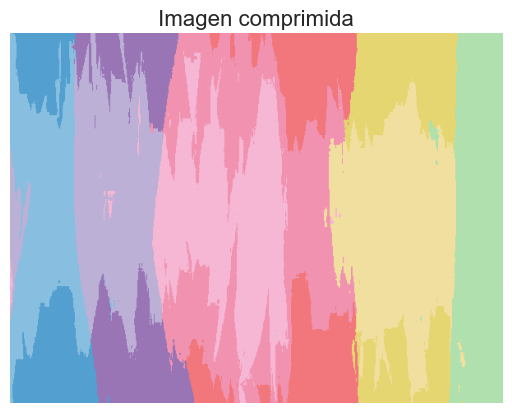

In [14]:
# Replace every pixel to its associated cluster centroid
df_temporal = df_image.copy().astype(float)
for i,rgb in enumerate(model_kmeans.cluster_centers_):
    df_temporal.loc[model_kmeans.labels_ == i, :] = rgb

# Plot compressed image with only k colors
image_compressed = df_temporal.values.reshape(image.shape[0], image.shape[1], 3).astype("uint8")
plt.imshow(image_compressed)
plt.axis("off")
plt.title("Imagen comprimida", fontsize=16)
plt.show()

#### **6.4.1.3) Revisión de los supuestos de _k-means_**

https://scikit-learn.org/1.5/auto_examples/cluster/plot_kmeans_assumptions.html#sphx-glr-auto-examples-cluster-plot-kmeans-assumptions-py

Los supuestos que se revisarán son los siguientes, así como una posible solución a los problemas inherentes a violar los supuestos.

> **Selección correcta de $k$**  
> Revisar la gráfica de codo con la inercia de ajustar diferentes modelos  

> **Grupos anisotrópicos (_no isotróicos_)**  
> Es preferible utilizar modelos _Gaussian Mixture_  

> **Varianza distinta**  
> Es preferible utilizar modelos _Gaussian Mixture_

> **Tamaño de clusters distintos**  
> Incrementar el número de iteraciones del algoritmo

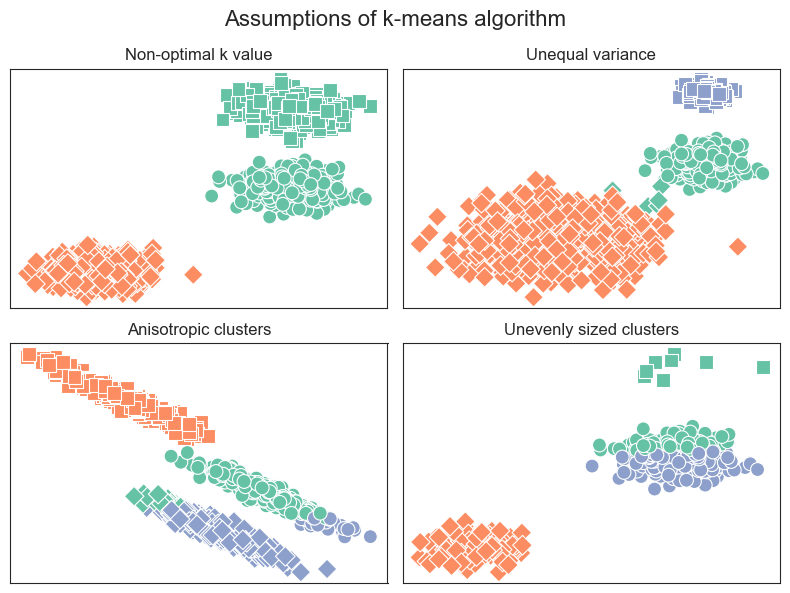

In [27]:
# Generate blobs
n_samples = 1500
random_state = 314159
X, y = make_blobs(n_samples=n_samples, random_state=random_state)

# Anisotropic blobs
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
X_aniso = np.dot(X, transformation)

# Unequal variance
X_unequal, y_unequal = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state)

# Unevenly sized blobs
X_uneven = np.vstack( (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10]) )  
y_uneven = [0] * 500 + [1] * 100 + [2] * 10

# Prepare plot grid
fig, axes = plt.subplots(2,2, figsize=(8,6))

# Non optimal k value
model_kmeans = KMeans(n_clusters=2, random_state=314159).fit(X)
sns.scatterplot(x=X[:,0], y=X[:,1], hue=model_kmeans.labels_, s=100, style=y, markers={0:"o",1:"D",2:"s"},
                palette="Set2",legend=False, ax=axes[0,0])
axes[0,0].set_xticks([]), axes[0,0].set_yticks([]), axes[0,0].set_title("Non-optimal k value")

# Unequal variance of clusters
model_kmeans = KMeans(n_clusters=3, random_state=314159).fit(X_unequal)
sns.scatterplot(x=X_unequal[:,0], y=X_unequal[:,1], hue=model_kmeans.labels_, s=100, style=y, markers={0:"o",1:"D",2:"s"},
                palette="Set2",legend=False, ax=axes[0,1])
axes[0,1].set_xticks([]), axes[0,1].set_yticks([]), axes[0,1].set_title("Unequal variance")

# Anisotropical distribution of clusters
model_kmeans = KMeans(n_clusters=3, random_state=314159).fit(X_aniso)
sns.scatterplot(x=X_aniso[:,0], y=X_aniso[:,1], hue=model_kmeans.labels_, s=100, style=y, markers={0:"o",1:"D",2:"s"},
                palette="Set2",legend=False, ax=axes[1,0])
axes[1,0].set_xticks([]), axes[1,0].set_yticks([]), axes[1,0].set_title("Anisotropic clusters")

# Unevenly sized clusters
model_kmeans = KMeans(n_clusters=3, random_state=314159).fit(X_uneven)
sns.scatterplot(x=X_uneven[:,0], y=X_uneven[:,1], hue=model_kmeans.labels_, s=100, style=y_uneven, markers={0:"o",1:"D",2:"s"},
                palette="Set2",legend=False, ax=axes[1,1])
axes[1,1].set_xticks([]), axes[1,1].set_yticks([]), axes[1,1].set_title("Unevenly sized clusters")

# Show plot
plt.suptitle("Assumptions of k-means algorithm", fontsize=16)
plt.tight_layout()
plt.show()

### **6.4.1) Algoritmo _DBSCAN_**

El algoritmo DBSCAN (_Density Based Scanning_) considera la clusterización por áreas de alta densidad separadas por áreas de baja densidad. Debido a esto, las áreas encontradas por este método pueden ser de cualquier forma, contrario a _k-means_, que asume que los cluster tienen forma convexa. 

El componente centrel del algoritmo es el concepto de individuos "nucleares" (de núcleo) o _core points_, que son los individuos que están en áreas de alta densidad. Un clúster es, por lo tanto, un conjunto de _core points_, cada uno cerca de otro y un subconjunto de individuos no nucleares.

Para implementar el algoritmo se necesitan dos medidas básicas, que definen lo que se considera como una zona con alta densidad:

> _eps_: (de _epsilon_) El radio de búsqueda de otros individuos.
>   
> _min_samples_: El número mínimo de individuos que deben estar dentro del radio de búsqueda para considerar a un individuo nuclear.

El algoritmo puede resumirse de la siguiente manera:
1) Encontrar todos los puntos nucleares a partir de _eps_ y _min_samples_
2) Aglomerar todos los puntos nucleares dentro de un cluster específico. Recuerde que un punto nuclear permite propagar un cluster
3) Para todos los puntos no nucleares, encontrar que punto nuclear se encuentra más cercano y asignarlo a dicho cluster. Recuerde que los puntos np nucleares solo pueden ser asignados a un cluster, pero no pueden propagarlo.

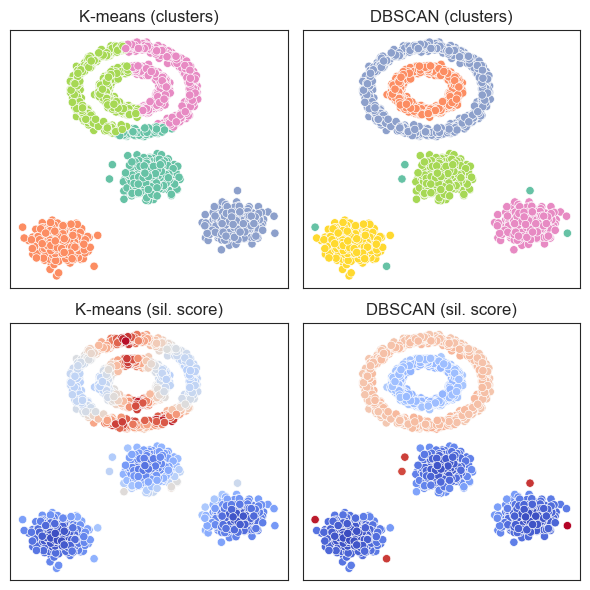

In [175]:
# Gather noisy circles and blobs data in a single dataset
mixed = [noisy_circles[0][:,:]*5, noisy_circles[1]]
mixed[0][:,1] = mixed[0][:,1]+12
mixed[0] = np.concatenate([mixed[0], blobs[0]])
mixed[1] = np.concatenate([mixed[1], blobs[1]+2])

# Create plot grid
fig, axes = plt.subplots(2,2, figsize=(6,6))

# Fit and plot k-means clusters
model_kmeans = KMeans(n_clusters=5, random_state=314159, n_init=25).fit(mixed[0])
sil_score = silhouette_samples(mixed[0], model_kmeans.labels_)
sns.scatterplot(x=mixed[0][:,0], y=mixed[0][:,1], legend=False, ax=axes[0,0], hue=model_kmeans.labels_, palette="Set2")
axes[0,0].set_title("K-means (clusters)"), axes[0,0].set_xticks([]), axes[0,0].set_yticks([])

# Plot k-means silhouette score
sil_score = silhouette_samples(mixed[0], model_kmeans.labels_)
sns.scatterplot(x=mixed[0][:,0], y=mixed[0][:,1], legend=False, ax=axes[1,0], hue=sil_score, palette="coolwarm_r")
axes[1,0].set_title("K-means (sil. score)"), axes[1,0].set_xticks([]), axes[1,0].set_yticks([])

# Fit and plot dbscan clusters
model_dbscan = DBSCAN(eps=1.0, min_samples=5).fit(mixed[0])
sns.scatterplot(x=mixed[0][:,0], y=mixed[0][:,1], legend=False, ax=axes[0,1], hue=model_dbscan.labels_, palette="Set2")
axes[0,1].set_title("DBSCAN (clusters)"), axes[0,1].set_xticks([]), axes[0,1].set_yticks([])

# Plot dbscan silhouette score
sil_score = silhouette_samples(mixed[0], model_dbscan.labels_)
sns.scatterplot(x=mixed[0][:,0], y=mixed[0][:,1], legend=False, ax=axes[1,1], hue=sil_score, palette="coolwarm_r")
axes[1,1].set_title("DBSCAN (sil. score)"), axes[1,1].set_xticks([]), axes[1,1].set_yticks([])

# Show figure
plt.tight_layout()
plt.show()

### **6.4.2) Algoritmo _Gaussian Mixture_**

Modelo probabilístico que asume que todas las observaciones son generdas de una mezcla de un número finito de distribuciones Gausianas Multivariadas con parámetros desconocidos. Puede considerarse como iuna generalización del método de _k-means_ para incorporar información sobre la estructura de covarianza de los datos, al igual que los centros de las distribuciones latentes. Se implementa mediante la maximización de verosimilitud.

#### **6.4.2.1) Generar datos**

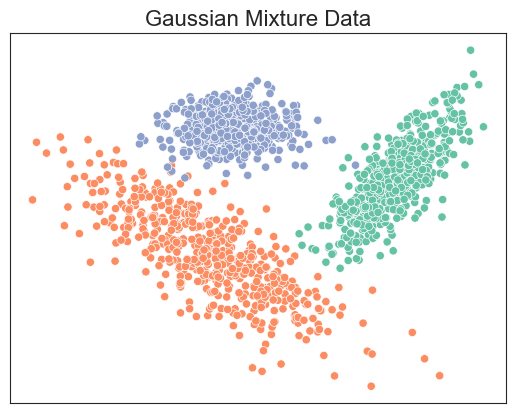

In [458]:
# Define Gaussian Mixture Data
random = np.random.RandomState(170)
a = random.multivariate_normal([5,5], [[2.0,0.75], [0.75, 0.50]], 500)
b = random.multivariate_normal([-2,-2], [[2.0,0.75], [0.75, 0.5]], 500)
b = b @ [[2.0,0], [0,-1.25]] + 1.0
c = random.multivariate_normal([-2,6], [[2.0, 0], [0, 0.10]], 500)
gmd = [ np.concatenate([a, b, c]), np.concatenate([np.full(500,0), np.full(500,1), np.full(500,2)])]

# Display data
sns.scatterplot(x=gmd[0][:,0], y=gmd[0][:,1], hue=gmd[1], palette="Set2", legend=False)
plt.xticks([]), plt.yticks([]), plt.title("Gaussian Mixture Data", fontsize=16)
plt.show()

#### **6.4.2.2) Función para dibujar intervalos de confianza de una distribución Gaussiana**

In [388]:
def make_ellipse(center=[0,0], covariance=[[3,1], [1,1]], conf_level=0.95):
    
    # Used to draw ellipse based on the confidence level and covariance matrix
    conf_scale = np.sqrt(chi2.ppf(conf_level, df=2))
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    
    # Generate ellipse in polar coordinates
    theta = np.linspace(0, 2 * np.pi, 100)
    ellipse = np.array([
        conf_scale * np.sqrt(eigenvalues[0]) * np.cos(theta),
        conf_scale * np.sqrt(eigenvalues[1]) * np.sin(theta)
    ])
    
    # Rotate and translate the ellipse
    ellipse = eigenvectors @ ellipse
    ellipse = ellipse + np.array(center)[:, np.newaxis]

    # Return X,Y points of generated ellipse
    return ellipse

#### **6.4.2.3) Ajustar modelo**

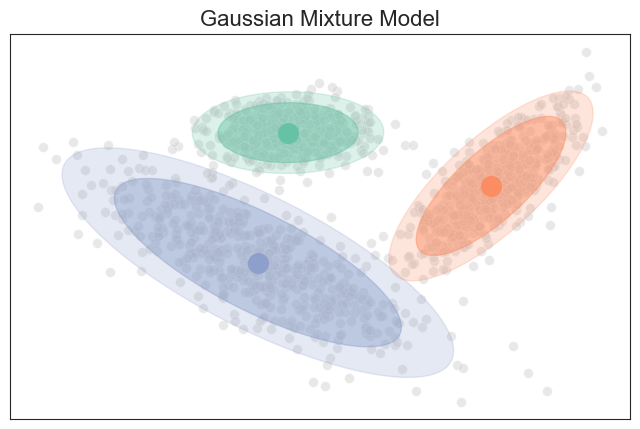

In [400]:
# Train model
model_gm = GaussianMixture(n_components=3, random_state=314159, covariance_type="full").fit(gmd[0])

#
plt.figure(figsize=(8,5))

# Scatter plot of observations
sns.scatterplot(x=gmd[0][:,0], y=gmd[0][:,1], color="lightgray", legend=False, s=50, alpha=0.50)

# Plot center of fitted gaussian distributions
palette = sns.color_palette("Set2")
for i in range(3):

    # Plot the center of the fitted Gaussian distributions
    plt.scatter(x=model_gm.means_[i,0], y=model_gm.means_[i,1], s=200, color=palette[i])
    
    # Plot confidence intervals of fitted Gaussian distributions
    levels = [0.95, 0.80]
    for level in levels:
        ellipse = make_ellipse(center=model_gm.means_[i], covariance=model_gm.covariances_[i], conf_level=level)
        plt.fill(ellipse[0,:], ellipse[1,:], color=palette[i], alpha=(1-level)**0.5)

# Settings and display plot
plt.xticks([]), plt.yticks([]), plt.title("Gaussian Mixture Model", fontsize=16)
plt.show()

#### **6.4.2.4) Suposiciones en las covarianzas**

Debido a que el algoritmo optimiza las medias y covarianzas de distribuciones NM, se pueden aplicar suposiciones sobre las matrices de varianza-covarianza, siendo cada una óptima para situaciones distintas. En el código debajo se muestran las distribuciones obtenidas de aplicar distintas suposiciones.

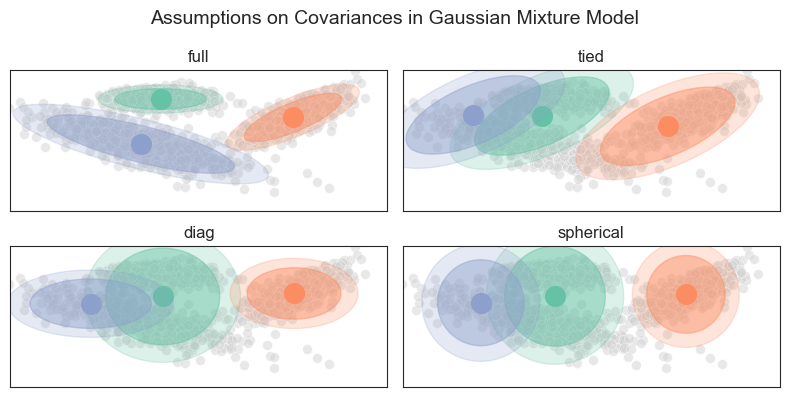

In [481]:
# Used to iterate over plot grid
fig, axes = plt.subplots(2,2, figsize=(8,4))
ax_i,ax_j = 0,0

# Iterate over each covariance type
cov_types = ["full", "tied", "diag", "spherical"]
for k,cov_type in enumerate(cov_types):

    # Jump to next row in plot grid and reset column index
    ax_i = ax_i+1 if ax_j>1 else ax_i
    ax_j = 0 if ax_j>1 else ax_j
    
    # Train model
    model_gm = GaussianMixture(n_components=3, random_state=314159, covariance_type=cov_type).fit(gmd[0])
    
    # Scatter plot of observations
    sns.scatterplot(x=gmd[0][:,0], y=gmd[0][:,1], color="lightgray", legend=False, s=50, alpha=0.50, ax=axes[ax_i,ax_j])
    
    # Plot center of fitted gaussian distributions
    palette = sns.color_palette("Set2")
    for i in range(3):
    
        # Plot the center of the fitted Gaussian distributions
        axes[ax_i,ax_j].scatter(x=model_gm.means_[i,0], y=model_gm.means_[i,1], s=200, color=palette[i])
        
        # Plot confidence intervals of fitted Gaussian distributions
        levels = [0.95, 0.80]
        for level in levels:
            if cov_type=="full":
                covariance = model_gm.covariances_[i]
            elif cov_type=="diag":
                covariance = np.diag(model_gm.covariances_[i])
            elif cov_type=="tied":
                covariance = model_gm.covariances_
            elif cov_type=="spherical":
                covariance = np.diag([model_gm.covariances_[i], model_gm.covariances_[i]])
            
            # Create fitted ellipses and plot them
            ellipse = make_ellipse(center=model_gm.means_[i], covariance=covariance, conf_level=level)
            axes[ax_i,ax_j].fill(ellipse[0,:], ellipse[1,:], color=palette[i], alpha=(1-level)**0.5)

            # Settings of subplot
            axes[ax_i,ax_j].set_xticks([]), axes[ax_i,ax_j].set_yticks([])
            axes[ax_i,ax_j].set_xlim(-10,10), axes[ax_i,ax_j].set_ylim(0,7.5)
            axes[ax_i,ax_j].set_title(cov_type, fontsize=12)

    # Jump to next column in plot grid
    ax_j += 1

# Settings and display plot
plt.suptitle("Assumptions on Covariances in Gaussian Mixture Model", fontsize=14)
plt.tight_layout()
plt.show()